# Data Loading

This notebook loads the raw salary dataset and performs a quick first inspection.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
sns.set_theme(style="whitegrid")

In [ ]:

# # Salary Prediction Project - Data Loading
# This notebook loads the raw salary dataset and performs the first inspection.
# Main goals:
# - Load the dataset
# - Understand rows and columns
# - Identify target variable
# - Identify possible features
# - Check missing values
# - Check duplicate rows
# - Inspect categorical values
# - Write first observations


df=pd.read_csv(Path("../data/raw/ds_salaries.csv"))
print(df.shape)

df.head()

df.tail()
df.sample(5)
df.info()


(607, 12)
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [34]:
col=df.columns.tolist()
print(col)
for c in range(len(col)):
    print(f"{col[c]} : {df[col[c]].dtype}")


['Unnamed: 0', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
Unnamed: 0 : int64
work_year : int64
experience_level : str
employment_type : str
job_title : str
salary : int64
salary_currency : str
salary_in_usd : int64
employee_residence : str
remote_ratio : int64
company_location : str
company_size : str


In [35]:
df.isnull().sum()
(df.isnull().sum()/len(df))*100


Unnamed: 0            0.0
work_year             0.0
experience_level      0.0
employment_type       0.0
job_title             0.0
salary                0.0
salary_currency       0.0
salary_in_usd         0.0
employee_residence    0.0
remote_ratio          0.0
company_location      0.0
company_size          0.0
dtype: float64

In [36]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


In [57]:
df_clean_view = df.drop(columns=["Unnamed: 0"], errors="ignore")

df_clean_view.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


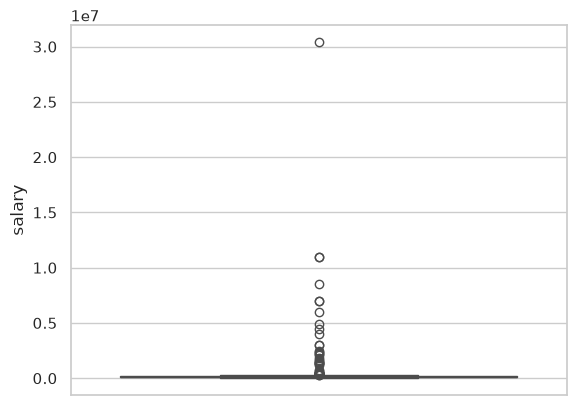

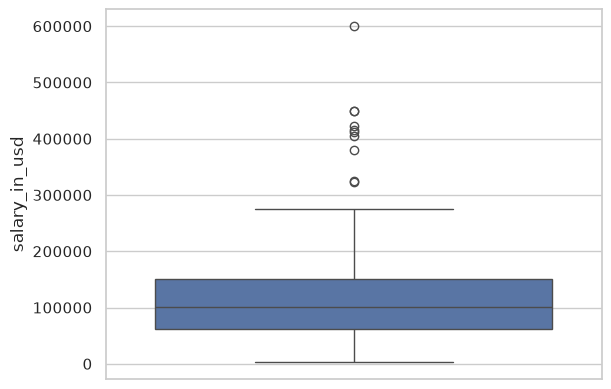

Target Variable: salary_in_usd


count       607.000000
mean     112297.869852
std       70957.259411
min        2859.000000
25%       62726.000000
50%      101570.000000
75%      150000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

In [64]:
sns.boxplot(df["salary"])
plt.show()
# IQR is getting calculated and any salary above that number becomes the outlier
sns.boxplot(df["salary_in_usd"])
plt.show()


#  what is the target bariable

target='salary_in_usd'
print(f'Target Variable: {target}')

df_clean_view[target].describe()



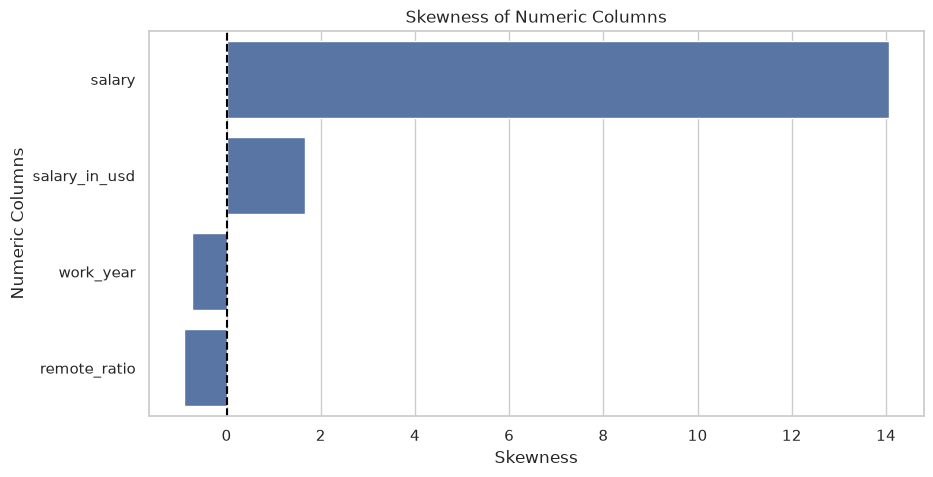

In [65]:
numeric_cols = df.select_dtypes(include=["number"]).columns

skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness

plt.figure(figsize=(10, 5))
sns.barplot(x=skewness.values, y=skewness.index)

plt.axvline(0, color="black", linestyle="--")
plt.title("Skewness of Numeric Columns")
plt.xlabel("Skewness")
plt.ylabel("Numeric Columns")
plt.show()
# check ed the skewness for more depth learning purpose






In [66]:
# feature selection here
# possible_features = [col for col in df.columns if col != target]
# print(possible_features)

possible_features=['work_year', 
'experience_level', 
'employment_type', 
'job_title', 
'salary', 
'salary_currency', 
'employee_residence', 
'remote_ratio', 
'company_location', 
'company_size']


columns_to_exclude = [
    "Unnamed: 0",
    "salary",
    "salary_currency",
    "salary_in_usd"
]

columns_to_exclude

['Unnamed: 0', 'salary', 'salary_currency', 'salary_in_usd']

In [73]:
categorical_columns = df_clean_view.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df_clean_view.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']

Numerical columns:
['work_year', 'salary', 'salary_in_usd', 'remote_ratio']


/tmp/ipykernel_38771/2815934567.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean_view.select_dtypes(include=["object"]).columns.tolist()


In [74]:
important_columns = [
    "experience_level",
    "employment_type",
    "company_size",
    "remote_ratio",
    "company_location",
    "employee_residence",
    "job_title"
]
for column in important_columns:
    print("=" * 60)
    print(f"Column: {column}")
    print(f"Unique values: {df_clean_view[column].nunique()}")
    print(df_clean_view[column].unique())

Column: experience_level
Unique values: 4
<StringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str
Column: employment_type
Unique values: 4
<StringArray>
['FT', 'CT', 'PT', 'FL']
Length: 4, dtype: str
Column: company_size
Unique values: 3
<StringArray>
['L', 'S', 'M']
Length: 3, dtype: str
Column: remote_ratio
Unique values: 3
[  0  50 100]
Column: company_location
Unique values: 50
<StringArray>
['DE', 'JP', 'GB', 'HN', 'US', 'HU', 'NZ', 'FR', 'IN', 'PK', 'CN', 'GR', 'AE',
 'NL', 'MX', 'CA', 'AT', 'NG', 'ES', 'PT', 'DK', 'IT', 'HR', 'LU', 'PL', 'SG',
 'RO', 'IQ', 'BR', 'BE', 'UA', 'IL', 'RU', 'MT', 'CL', 'IR', 'CO', 'MD', 'KE',
 'SI', 'CH', 'VN', 'AS', 'TR', 'CZ', 'DZ', 'EE', 'MY', 'AU', 'IE']
Length: 50, dtype: str
Column: employee_residence
Unique values: 57
<StringArray>
['DE', 'JP', 'GB', 'HN', 'US', 'HU', 'NZ', 'FR', 'IN', 'PK', 'PL', 'PT', 'CN',
 'GR', 'AE', 'NL', 'MX', 'CA', 'AT', 'NG', 'PH', 'ES', 'DK', 'RU', 'IT', 'HR',
 'BG', 'SG', 'BR', 'IQ', 'VN', 'BE', 'UA', 'MT', 'CL

In [ ]:
## Meanin
### experience_level

- EN = Entry-level / Junior
- MI = Mid-level
- SE = Senior-level
- EX = Executive-level

### employment_type

- FT = Full-time
- PT = Part-time
- CT = Contract
- FL = Freelance

### company_size

- S = Small
- M = Medium
- L = Large

### remote_ratio

- 0 = Onsite
- 50 = Hybrid
- 100 = Fully-Remote

In [ ]:
# ## Step 1 Summary

# ### Dataset Size

# The dataset contains 607 rows and 12 columns.

# Each row represents one salary record.

# ### Target Variable

# The target variable is:

# `salary_in_usd`

# This is the best target because all salaries are converted into USD, making salaries comparable across countries and currencies.

# ### Possible Features

# The possible input features are:

# - work_year
# - experience_level
# - employment_type
# - job_title
# - employee_residence
# - remote_ratio
# - company_location
# - company_size

# These columns describe the employee, job, company, and work setup.

# ### Columns Not Used For Training

# The following columns should not be used as input features:

# - Unnamed: 0
# - salary
# - salary_currency
# - salary_in_usd

# `Unnamed: 0` is just an index-like column.

# `salary_in_usd` is the target variable.

# `salary` and `salary_currency` may cause data leakage because they directly relate to salary.

# ### Missing Values

# There are no missing values in the dataset.

# ### Duplicate Rows

# There are no duplicate rows in the dataset.

# ### Categorical Columns

# Main categorical columns are:

# - experience_level
# - employment_type
# - job_title
# - salary_currency
# - employee_residence
# - company_location
# - company_size

# These columns will need encoding before model training.

# ### Numerical Columns

# Main numerical columns are:

# - work_year
# - salary
# - salary_in_usd
# - remote_ratio

# For model training, `work_year` and `remote_ratio` can be used as numerical features.

# `salary` and `salary_in_usd` should not be used as input features.

# ### Initial Observations

# This dataset is suitable for a Linear Regression salary prediction project.

# The most important features are likely:

# - experience_level
# - job_title
# - company_location
# - company_size
# - remote_ratio
# - work_year

# Some columns, especially `job_title`, `company_location`, and `employee_residence`, may have many unique categories. These will need careful handling during feature engineering.



# Full report to be read>